In [ ]:
from helperfunctions import helper as hfn
from helperfunctions import intern_constants as ic
from helperfunctions.pretty_print import PrettyPrint as pp
from pathlib import Path
from glob import glob
import os
import pandas as pd
%matplotlib widget



In [2]:
cfg1 = hfn.TrainConfig(config_name="val1", choose_val_set=1)
cfg2 = hfn.TrainConfig(config_name="val2", choose_val_set=2)
cfg3 = hfn.TrainConfig(config_name="part1", part1=True)

{
  "config_name": "val1",
  "batch_size": 252,
  "epochs": 30,
  "lr": 0.001,
  "weight_decay": 0.0,
  "grad_clip_norm": 1.0,
  "patience": 5,
  "min_delta": 1e-06,
  "depth": null,
  "input_dim": 38,
  "base_width": 38,
  "width_decay": 0.5,
  "bottleneck_min": 2,
  "activation": "relu",
  "dropout": 0.0,
  "leaky_relu_slope": null,
  "seed": 32,
  "base_seed": 32,
  "T0": 10,
  "Tmult": 2,
  "eta_min_lower_bound": 1e-06,
  "val_split": 0.4,
  "layer_depths": [
    2,
    3,
    4,
    5
  ],
  "available_start": "2019-04-05 14:00:00",
  "available_end": "2022-12-31 23:50:00",
  "min_gap": 4320,
  "val_start_time": "2019-05-13 13:00:00",
  "val_end_time": "2019-10-06 22:20:00",
  "test_start_time": "2020-05-01 04:10:00",
  "test_end_time": "2022-12-31 23:50:00",
  "signal_cols": [
    "Ambient temperature (converter) (°C)",
    "Drive train acceleration (mm/ss)",
    "Gear oil inlet pressure (bar)",
    "Gear oil pump pressure (bar)",
    "Gearbox speed (RPM)",
    "Generator bearing

In [3]:
print(f"Train:{(ic.TRAIN_START, ic.TRAIN_END)}")
print(f"Val1: {cfg1.val_start_time, cfg1.val_end_time}")
print(f"Val2 from cfg2: {cfg2.val_start_time, cfg2.val_end_time}")
print(f"Val2 from cfg3: {cfg3.val_start_time, cfg3.val_end_time}")
print(f"Test from cfg1: {(cfg1.test_start_time, cfg1.test_end_time)}")
print(f"Test from cfg2: {(cfg2.test_start_time, cfg2.test_end_time)}")
print(f"Test from cfg3: {(cfg3.test_start_time, cfg3.test_end_time)}")

Train:('2018-04-05 13:50:00', '2019-04-05 13:50:00')
Val1: (Timestamp('2019-05-13 13:00:00'), Timestamp('2019-10-06 22:20:00'))
Val2 from cfg2: (Timestamp('2019-11-06 18:40:00'), Timestamp('2020-04-01 04:00:00'))
Val2 from cfg3: (Timestamp('2019-11-06 18:40:00'), Timestamp('2020-04-01 04:00:00'))
Test from cfg1: (Timestamp('2020-05-01 04:10:00'), Timestamp('2022-12-31 23:50:00'))
Test from cfg2: (Timestamp('2020-05-01 04:10:00'), Timestamp('2022-12-31 23:50:00'))
Test from cfg3: (Timestamp('2019-11-06 18:40:00'), Timestamp('2020-04-01 04:00:00'))


In [4]:
time_periods = {
    "Train": (ic.TRAIN_START, ic.TRAIN_END),
    "Val1": (cfg1.val_start_time, cfg1.val_end_time),
    "Val2": (cfg3.val_start_time, cfg3.val_end_time),
    "Test": (cfg1.test_start_time, cfg1.test_end_time),
}


In [5]:
fp = glob(os.path.join(ic.PATH_IMPUTED, "*.csv"))[0]

wt_df = pd.read_csv(fp, parse_dates=[ic.TS_COL])
global_min = wt_df[ic.TS_COL].min()
global_max = wt_df[ic.TS_COL].max()

print(f"global_min={global_min}")
print(f"global_max={global_max}")

global_min=2016-06-27 18:00:00
global_max=2022-12-31 23:50:00


C:\Users\admin\Uni\Abschlussarbeit\github\BSc-Thesis-Multi-Wind-Turbine-AD\src\helperfunctions\pretty_print.py:1091: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  boundaries = sorted(pd.unique(boundaries))


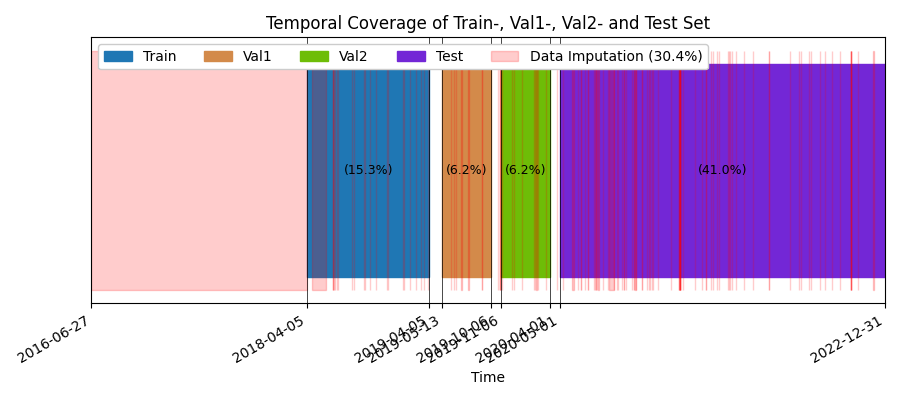

In [6]:
os.makedirs(ic.PATH_PRINTS, exist_ok=True)
pp.plot_dataset_time_periods(
    time_periods=time_periods,
    title="Temporal Coverage of Train-, Val1-, Val2- and Test Set",
    save_path= Path(ic.PATH_PRINTS / "dataset_overview.png"),
    global_start=global_min,
    global_end= global_max,
    figsize=(9,4)
)

### ratio of NaNs 

In [8]:
fps = sorted(glob(os.path.join(ic.PATH_PENMANSHIEL, "WT_Data_Complete_ID_*.csv")))

    



In [13]:
n_rows_total: int = 0
n_total_cells: int = 0
n_missing_cells: int = 0

for fp in fps:
    df = pd.read_csv(fp)
    df = df.drop(columns=[ic.TS_COL])
    n_rows = len(df)
    n_signals = len(df.columns)
    n_rows_total += n_rows
    n_total_cells += n_rows * n_signals
    n_missing_cells += int(df.isna().sum().sum())

glob_missing: float = n_missing_cells / n_total_cells

In [14]:
print(f"Total number of timestamps: {n_rows_total}")
print(f"Total signal cells: {n_total_cells}")
print(f"Missing signal cells: {n_missing_cells}")
print(f"Global signal-wise missing ratio {glob_missing:.4%}")

Total number of timestamps: 4799792
Total signal cells: 1747124288
Missing signal cells: 629906520
Global signal-wise missing ratio 36.0539%


In [7]:
files = list(ic.PATH_PENMANSHIEL.glob("WT_data*"))
display(files)

fp = files[0]

df = pd.read_csv(fp)
display(len(df.columns))

[WindowsPath('C:/Users/admin/Uni/Abschlussarbeit/github/BSc-Thesis-Multi-Wind-Turbine-AD/src/Penmanshiel/WT_Data_Complete_ID_1.csv'),
 WindowsPath('C:/Users/admin/Uni/Abschlussarbeit/github/BSc-Thesis-Multi-Wind-Turbine-AD/src/Penmanshiel/WT_Data_Complete_ID_10.csv'),
 WindowsPath('C:/Users/admin/Uni/Abschlussarbeit/github/BSc-Thesis-Multi-Wind-Turbine-AD/src/Penmanshiel/WT_Data_Complete_ID_11.csv'),
 WindowsPath('C:/Users/admin/Uni/Abschlussarbeit/github/BSc-Thesis-Multi-Wind-Turbine-AD/src/Penmanshiel/WT_Data_Complete_ID_12.csv'),
 WindowsPath('C:/Users/admin/Uni/Abschlussarbeit/github/BSc-Thesis-Multi-Wind-Turbine-AD/src/Penmanshiel/WT_Data_Complete_ID_13.csv'),
 WindowsPath('C:/Users/admin/Uni/Abschlussarbeit/github/BSc-Thesis-Multi-Wind-Turbine-AD/src/Penmanshiel/WT_Data_Complete_ID_14.csv'),
 WindowsPath('C:/Users/admin/Uni/Abschlussarbeit/github/BSc-Thesis-Multi-Wind-Turbine-AD/src/Penmanshiel/WT_Data_Complete_ID_15.csv'),
 WindowsPath('C:/Users/admin/Uni/Abschlussarbeit/github/

365